<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21613 non-null  int64  
 1   date           21613 non-null  object 
 2   price          21613 non-null  float64
 3   bedrooms       21613 non-null  int64  
 4   bathrooms      21613 non-null  float64
 5   sqft_living    21613 non-null  int64  
 6   sqft_lot       21613 non-null  int64  
 7   floors         21613 non-null  float64
 8   waterfront     21613 non-null  int64  
 9   view           21613 non-null  int64  
 10  condition      21613 non-null  int64  
 11  grade          21613 non-null  int64  
 12  sqft_above     21613 non-null  int64  
 13  sqft_basement  21613 non-null  int64  
 14  yr_built       21613 non-null  int64  
 15  yr_renovated   21613 non-null  int64  
 16  zipcode        21613 non-null  int64  
 17  lat            21613 non-null  float64
 18  long  

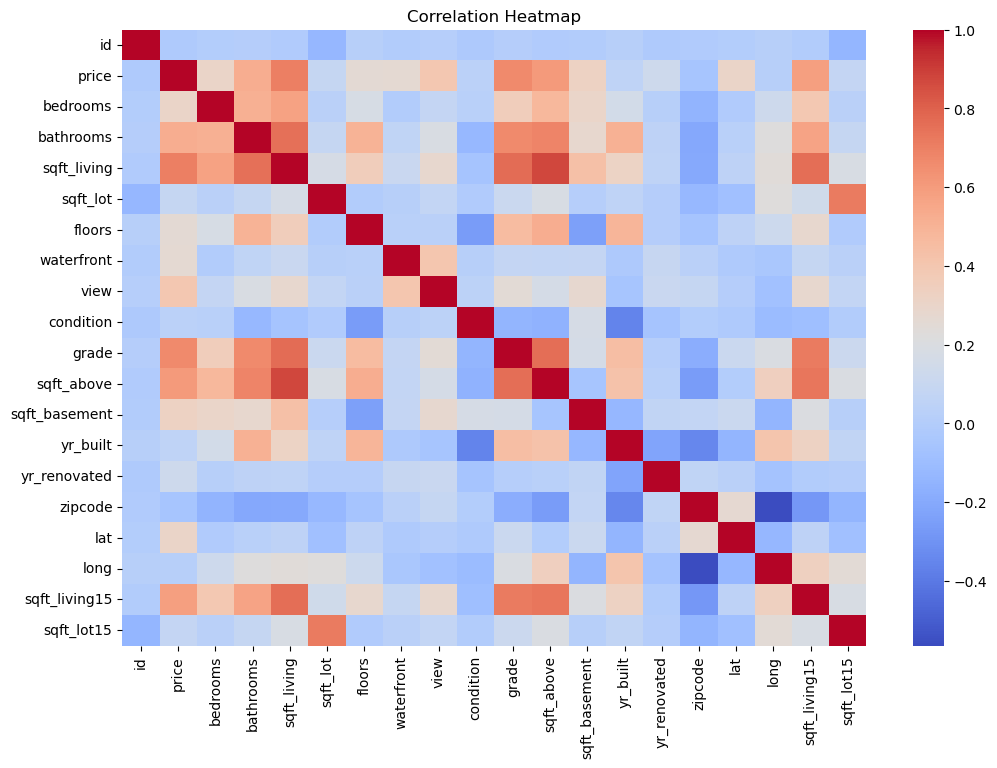

MAE : 166257.61943338934
MSE : 67596607329.957726
RMSE : 259993.47555267176
R2 Score : 0.5528636234983877


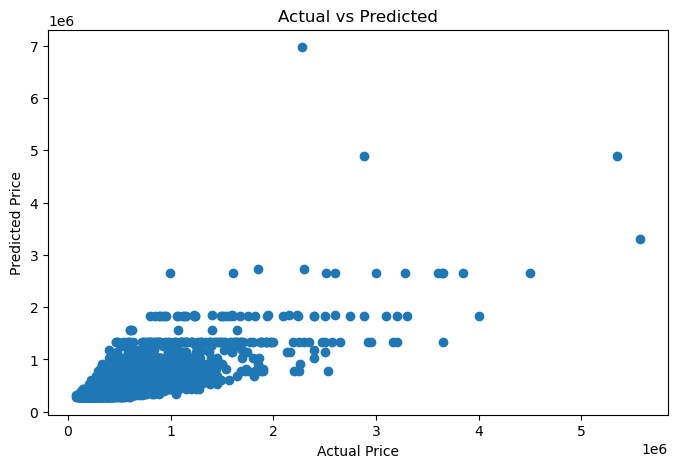

Model Saved Successfully


In [1]:
# ==========================================
# IMPORT LIBRARIES
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# ==========================================
# LOAD DATASET
# ==========================================

df = pd.read_csv("../data/kc_house_data.csv")

# ==========================================
# DATASET HEAD
# ==========================================

df.head()

# ==========================================
# SHAPE
# ==========================================

df.shape

# ==========================================
# INFO
# ==========================================

df.info()

# ==========================================
# NULL VALUES
# ==========================================

df.isnull().sum()

# ==========================================
# DESCRIBE
# ==========================================

df.describe()

# ==========================================
# CORRELATION HEATMAP
# ==========================================

plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(numeric_only=True),
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

# ==========================================
# SELECT FEATURES
# ==========================================

X = df[[
    "bedrooms",
    "bathrooms",
    "sqft_living",
    "floors",
    "waterfront",
    "view",
    "condition",
    "sqft_above"
]]

# ==========================================
# TARGET
# ==========================================

y = df["price"]

# ==========================================
# TRAIN TEST SPLIT
# ==========================================

x_train, x_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# ==========================================
# SCALING
# ==========================================

scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)

x_test_scaled = scaler.transform(x_test)

# ==========================================
# DECISION TREE REGRESSOR
# ==========================================

model = DecisionTreeRegressor(
    max_depth=5,
    random_state=42
)

# ==========================================
# TRAIN MODEL
# ==========================================

model.fit(
    x_train_scaled,
    y_train
)

# ==========================================
# PREDICTIONS
# ==========================================

y_pred = model.predict(
    x_test_scaled
)

# ==========================================
# METRICS
# ==========================================

mae = mean_absolute_error(
    y_test,
    y_pred
)

mse = mean_squared_error(
    y_test,
    y_pred
)

rmse = np.sqrt(mse)

r2 = r2_score(
    y_test,
    y_pred
)

print("MAE :", mae)

print("MSE :", mse)

print("RMSE :", rmse)

print("R2 Score :", r2)

# ==========================================
# ACTUAL VS PREDICTED
# ==========================================

plt.figure(figsize=(8,5))

plt.scatter(
    y_test,
    y_pred
)

plt.xlabel("Actual Price")

plt.ylabel("Predicted Price")

plt.title("Actual vs Predicted")

plt.show()

# ==========================================
# CREATE MODELS FOLDER
# ==========================================

os.makedirs(
    "../models",
    exist_ok=True
)

# ==========================================
# SAVE MODEL
# ==========================================

joblib.dump(
    model,
    "../models/decision_tree_regressor.pkl"
)

joblib.dump(
    scaler,
    "../models/scaler.pkl"
)

print("Model Saved Successfully")